In [ ]:
try:
    import firedrake
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/firedrake-install-release-real.sh" -O "/tmp/firedrake-install.sh" && bash "/tmp/firedrake-install.sh"
    import firedrake

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [1]:
from firedrake import *
import matplotlib.pyplot as plt
import numpy as np

from firedrake.petsc import PETSc

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


In [2]:
# Get current path: all relative paths that you may use for input/output start from here.
#
# - Colab:  The default path is /content, and your GDrive folder is accessible (if mounted) at /content/drive/MyDrive
#
# - local:  If running on your local machine, current_path is the position WHERE YOU LAUNCHED THE NOTEBOOK KERNEL BY 'jupyter notebook'
#           and NOT the directory in which this ipynb file is saved.
#           If you want to modify your current path, go to the terminal, stop the kernel (ctrl-C + press y), then move to the desired path by
#           cd my/desired/path/starting/from/here
#           and then launch 'jupyter notebook'.
import os
current_path = os.getcwd()
print(current_path)

my_io_path = current_path + "/cfd-labs/Lab11-NS-Boussinesq/"
# my_io_path = current_path+"/"
print(my_io_path)

/home/aless
/home/aless/cfd-labs/Lab11-NS-Boussinesq/


---
---
# Exercise 1
## Coupling Navier-Stokes with thermal problem, according to Boussinesq buoyancy.

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (31,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (32,) is empty. This is likely an error. Did you choose the right label?


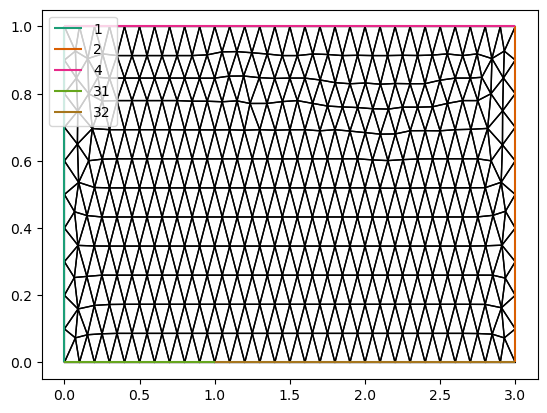

In [3]:
# Import mesh: set the path correctly!
# See cell before Exercise 1 about current path.
mesh = Mesh(my_io_path+'mesh/hotplate.msh')
fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend(loc='upper left')

In [11]:
# Function spaces
V = VectorFunctionSpace(mesh, 'P', 2)   # velocity
Q = FunctionSpace(mesh, 'P', 1)         # pressure
W = MixedFunctionSpace([V, Q])
Z = FunctionSpace(mesh, 'P', 1)         # temperature

# Data and boundary conditions
nu = Constant(0.1)
k = Constant(1.e-2)
beta = Constant(1.e-3)
g = Constant((0,-9.8))
T_ref = Constant(0)
f = Constant((0.,0.))

u_in = Constant((1.,0.))
bcNS_in = DirichletBC(W.sub(0), u_in, 1)
bcNS_sym = DirichletBC(W.sub(0).sub(1), Constant(0.0), (31, 4))
bcNS_plate = DirichletBC(W.sub(0), Constant((0.0,0.0)), 32)
bcsNS = (bcNS_in, bcNS_sym, bcNS_plate)

T_in = Constant(10.0)
T_plate = Constant(20.0)
bcT_in = DirichletBC(Z, T_in, 1)
bcT_plate = DirichletBC(Z, T_plate, 32)
bcsT = (bcT_in, bcT_plate)

### Variational problems

In [12]:
def nonlinear_iteration_NS(u, v, p, q, nu, beta, g, T_ref, f, T, u_old):
    # Implementing fixed-point method for Navier-Stokes equations with thermal source.
    # u,p   :   TrialFunctions
    # v,q   :   TestFunctions
    # f     :   rhs of NS momentum equation
    # T     :   temperature Function
    # u_old :   advecting velocity Function

    a = nu * inner(grad(u), grad(v)) * dx  \
        + inner(dot(grad(u), u_old), v) * dx  \
        - div(v) * p * dx  \
        + q * div(u) * dx
    L = inner(f, v) * dx \
        - beta * (T - T_ref) * inner(g, v) * dx

    return a, L

def nonlinear_iteration_thermal(T, eta, k, f, u):
    # Implementing fixed-point method for Navier-Stokes equations with thermal source.
    # T     :   TrialFunction
    # eta   :   TestFunction
    # f     :   rhs of thermal equation
    # u     :   advecting velocity Function

    a = k * inner(grad(T), grad(eta)) * dx  \
        + inner(grad(T), u) * eta * dx
    L = f * eta * dx

    return a, L

### Initialization and post-processing setup.

NameError: name 'File' is not defined

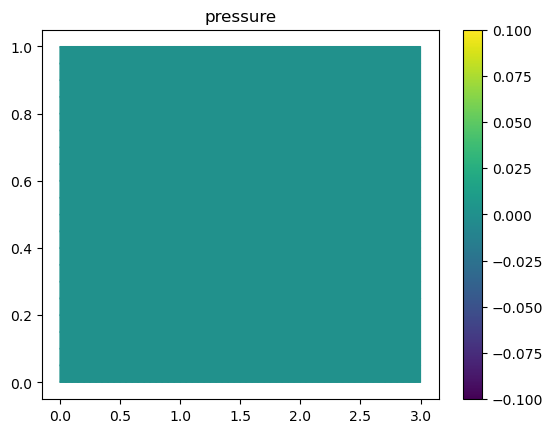

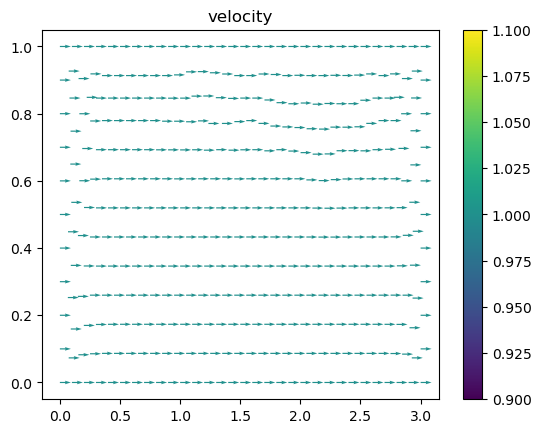

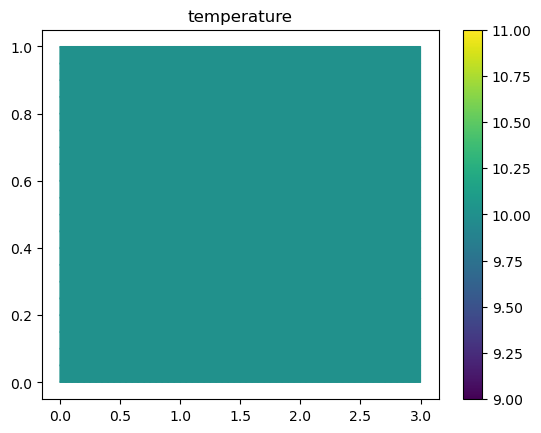

In [13]:
# Initialization
wh = Function(W)
uh, ph = wh.subfunctions
uh.interpolate(u_in)
Th = Function(Z)
Th.interpolate(T_in)

# Plot of initial guess
fig, ax = plt.subplots()
col = tripcolor(ph, axes=ax)
plt.colorbar(col)
plt.title('pressure')
fig, ax = plt.subplots()
col = quiver(uh, axes=ax)
plt.colorbar(col)
plt.title('velocity')
fig, ax = plt.subplots()
col = tripcolor(Th, axes=ax)
plt.colorbar(col)
plt.title('temperature')

# vtk output for Paraview
basename = 'lab11_'
outfileU = File(my_io_path+"output/"+basename+"velocity.pvd")
outfileP = File(my_io_path+"output/"+basename+"pressure.pvd")
outfileT = File(my_io_path+"output/"+basename+"temperature.pvd")
uh.rename("Velocity")   # this name will be used in Paraview
ph.rename("Pressure")   # this name will be used in Paraview
Th.rename("Temperature")   # this name will be used in Paraview
outfileU.write(uh)
outfileP.write(ph)
outfileT.write(Th)

### Definition of the ***linear*** solvers for each nonlinear iteration.

In [14]:
u, p = TrialFunctions(W)
v, q = TestFunctions(W)
u_old = Function(V)
u_old.assign(uh)    # copy the dof's of uh (defined over W) into u_old (defined over V)
                    # Do not use 'u_old = uh', which would yield a "shallow copy", by which
                    # u_old would contain a sort of pointer to uh: in such case, any update of uh
                    # would immediately reflect on u_old, whilst we want to keep the two functions
                    # separate from one another, and update them only when actually intended.
p_old = Function(Q)
p_old.assign(ph)
a_NS, L_NS = nonlinear_iteration_NS(u, v, p, q, nu, beta, g, T_ref, f, Th, u_old)
pb_NS = LinearVariationalProblem(a_NS, L_NS, wh, bcsNS)
solver_NS =  LinearVariationalSolver(pb_NS)#, solver_parameters=param)

T = TrialFunction(Z)
eta = TestFunction(Z)
T_old = Function(Z)
T_old.assign(Th)
a_T, L_T = nonlinear_iteration_thermal(T, eta, k, Constant(0.0), uh)
pb_T = LinearVariationalProblem(a_T, L_T, Th, bcsT)
solver_T =  LinearVariationalSolver(pb_T)#, solver_parameters=param)

### Iterative algorithm for the solution of the nonlinear problem

In [ ]:
maxit = 100
it = 0
tol = 1e-4
err = tol+1     # >tol in order to enter the loop at the beginning

while it <= maxit and err > tol:

    it += 1

    solver_NS.solve()
    uh, ph = wh.subfunctions
    solver_T.solve()

    err = (errornorm(uh, u_old, 'H1') / norm(u_old, 'H1') +
           errornorm(Th, T_old, 'H1') / norm(T_old, 'H1'))

    print("Iteration = ", it, " Error = ", err)
    uh.rename("Velocity")
    ph.rename("Pressure")
    Th.rename("Temperature")
    outfileU.write(uh)
    outfileP.write(ph)
    outfileT.write(Th)

    u_old.assign(uh) # update the old solution
    p_old.assign(ph) # update the old solution
    T_old.assign(Th) # update the old solution

if it <= maxit:
    print('Nonlinear solver converged in', it, 'iterations.')
else:
    print('Nonlinear solver did NOT converge!\nRelative error =', err, 'after', it, 'iterations.')

Iteration =  1  Error =  3.2076167824780697
Iteration =  2  Error =  0.07291230511830117
Iteration =  3  Error =  0.004138334831796395
Iteration =  4  Error =  0.00020862039795512262
Iteration =  5  Error =  1.0125011255182538e-05
Nonlinear solver converged in 5 iterations.


Text(0.5, 1.0, 'temperature')

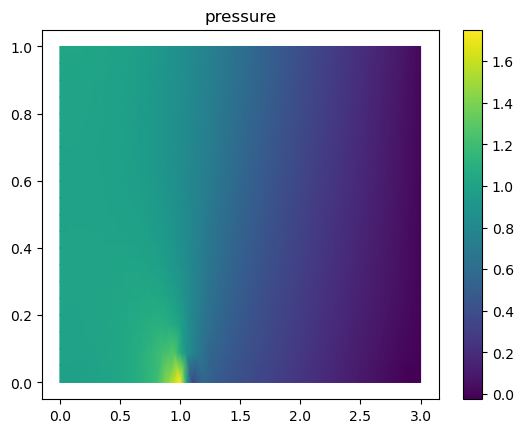

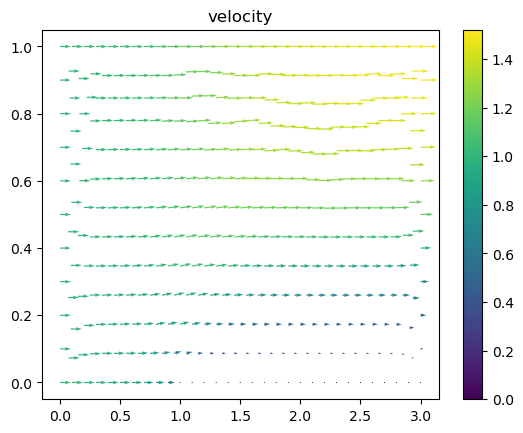

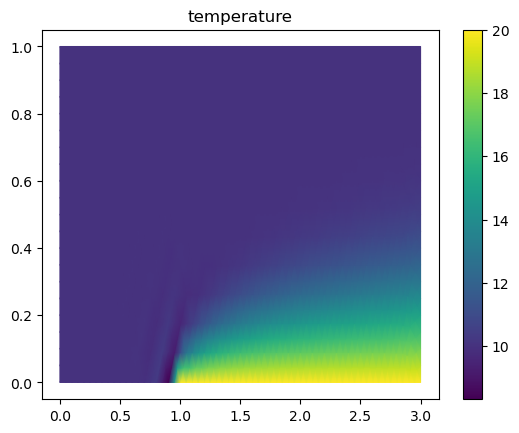

In [17]:
fig, ax = plt.subplots()
col = tripcolor(ph, axes=ax)
plt.colorbar(col)
plt.title('pressure')
fig, ax = plt.subplots()
col = quiver(uh, axes=ax)
plt.colorbar(col)
plt.title('velocity')
fig, ax = plt.subplots()
col = tripcolor(Th, axes=ax)
plt.colorbar(col)
plt.title('temperature')

### Point 4: stabilization

In [ ]:
# Only the thermal problem needs to be stabilized -> SUPG

def nonlinear_iteration_thermal(T, eta, k, f, u):
    # Implementing fixed-point method for Navier-Stokes equations with thermal source.
    # T     :   TrialFunction
    # eta   :   TestFunction
    # f     :   rhs of thermal equation
    # u     :   advecting velocity Function

    # coefficient delta_K
    ubar = Function(FunctionSpace(mesh, 'DG', 0))
    ubar.project(sqrt(inner(u, u)))
    h = CellDiameter(mesh)
    delta_K = Function(ubar.function_space())
    delta_K = 0.5 * h / (ubar+1e-15) # piece-w lin Function

    a = k * inner(grad(T), grad(eta)) * dx  \
        + inner(grad(T), u) * eta * dx \
        + delta_K * (- k * div(grad(T)) + inner(u, grad(T)) ) * \
            (inner(u, grad(eta)) + 0.5 * div(u) * eta) * dx
    L = f * eta * dx

    return a, L

Then, run all the cells of Exercise 1 starting with 'Initialization'.
